# Task 1

## Part 1

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.


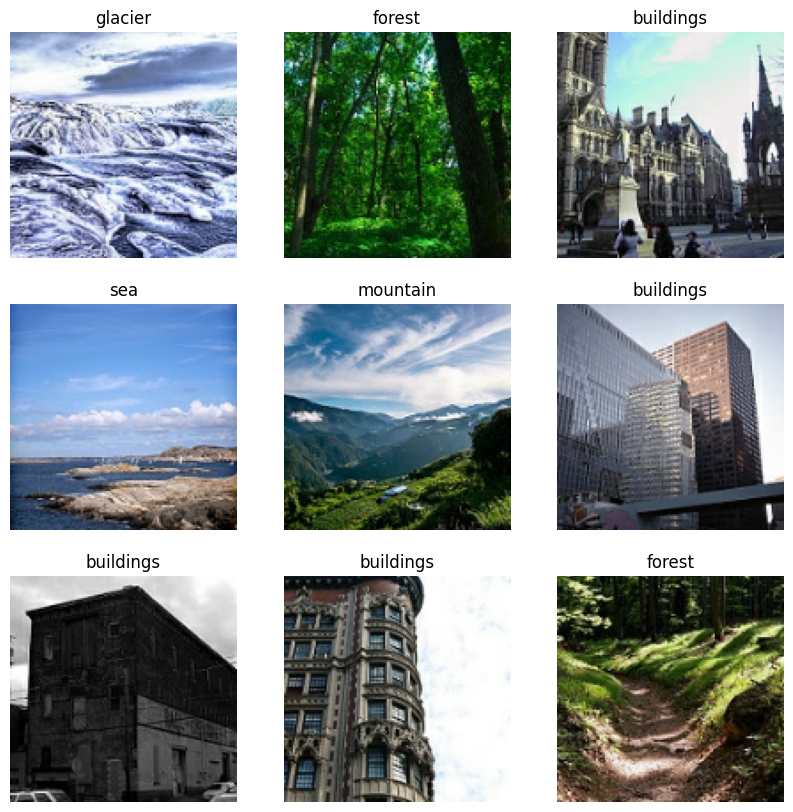

In [ ]:
import kagglehub
import tensorflow as tf
import matplotlib.pyplot as plt
import pathlib

path = kagglehub.dataset_download("puneet6060/intel-image-classification")
data_dir = pathlib.Path(path)

train_dir = data_dir / "seg_train" / "seg_train"
test_dir = data_dir / "seg_test" / "seg_test"

# Set the hyperparameters
batch_size = 32
img_height = 128
img_width = 128

# Prepare the training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
  train_dir,
  validation_split=0.2,
  subset="training",
  seed=777,
  image_size=(img_height, img_width),
  batch_size=batch_size)

# Prepare the validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
  train_dir,
  validation_split=0.2,
  subset="validation",
  seed=777,
  image_size=(img_height, img_width),
  batch_size=batch_size)

# Prepare the test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_dir,
  seed=777,
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names

# Visualize the dataset
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)

    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

# Optimize data loading performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

For this image classification task, I have selected the Intel Image Classification Dataset. This dataset was originally published by Intel for an image classification challenge and contains approximately 25,000 images of natural scenes worldwide. The images are distributed across six distinct classes: buildings, forest, glacier, mountain, sea, and street. I chose this dataset as the classes feature a mix of distinct geometric shapes (such as buildings and streets) and organic textures (i.e. forests and seas), making it an excellent benchmark for evaluating a convolutional neural network's ability to learn diverse spatial features.

In [ ]:
from tensorflow.keras import layers, models, Input

num_classes = len(class_names)

model = models.Sequential([
  # Use an explicit Input layer to define the shape
  Input(shape=(img_height, img_width, 3)),
  layers.Rescaling(1./255),

  # Convolutional Base
  layers.Conv2D(32, (3, 3), activation='relu'),
  layers.MaxPooling2D(2, 2),

  layers.Conv2D(64, (3, 3), activation='relu'),
  layers.MaxPooling2D(2, 2),

  layers.Conv2D(128, (3, 3), activation='relu'),
  layers.MaxPooling2D(2, 2),

  # Final Dense Layers
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

I chose a standard VGG-style pattern consisting of three alternating sets of Convolutional (Conv2D) and MaxPooling layers. The Conv2D layers use a 3x3 kernel to progressively extract hierarchical features from the images. The early layers capture simple features like edges and textures, while the deeper layers (with 64 and 128 filters) capture more complex, dataset-specific patterns.

I placed a MaxPooling2D layer after each Conv2D layer to downsample the spatial dimensions of the feature maps. This reduces the computational load, mitigates overfitting by reducing the number of parameters, and provides a degree of translation invariance. Finally, the network is flattened and passed through a Dense layer to map the extracted visual features to the final classification probabilities.

In [ ]:
# Compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# Train the model
epochs = 10

history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

# Evaluate the model on the test set
print("\n--- Final Evaluation ---")
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Final Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 56s 50ms/step - accuracy: 0.6023 - loss: 1.0260 - val_accuracy: 0.6041 - val_loss: 0.9905
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7417 - loss: 0.7090 - val_accuracy: 0.7491 - val_loss: 0.6672
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8094 - loss: 0.5301 - val_accuracy: 0.7883 - val_loss: 0.5833
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8588 - loss: 0.3959 - val_accuracy: 0.7926 - val_loss: 0.6007
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9072 - loss: 0.2666 - val_accuracy: 0.7958 - val_loss: 0.6514
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9344 - loss: 0.1883 - val_accuracy: 0.7880 - val_loss: 0.8174
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9629 - loss: 0.1109 - val_accuracy: 0.7691 - val_loss: 1.1207
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9633 - loss: 0.1032 - val_acc

Final Test Metrics:
- Final Test Accuracy: 79.77%
- Final Test Loss: 1.0623

Accuracy, which represents the percentage of images in the unseen test set that the model correctly assigned to the proper category, and loss (specifically sparse categorical cross-entropy), which measures the mathematical difference between the model's predicted probability distribution and the actual true labels, were the selected metrics.

During training, by epoch 10, the training accuracy was nearly perfect (98.67%) and the training loss was exceptionally small (0.0416). However, the validation loss actually started increasing after epoch 3, climbing all the way to 1.0772, while validation accuracy stalled around 79%.

This suggests that around epoch 4, the model stopped learning general features of the images and started simply memorizing the specific training data. When it was tested on the unseen data, it was unable perform any better than ~80%.

## Part 2

 I will select the VGG16 model as it has an architecture similar to the custom one implemented in Part 1.

In [ ]:
from tensorflow.keras.applications import VGG16

# Load the pre-trained VGG16 model
# include_top=False to drop the original 1000-class ImageNet classifier
base_model = VGG16(input_shape=(128, 128, 3),
                   include_top=False,
                   weights='imagenet')

# Freeze the base model to not destroy its pre-trained weights
base_model.trainable = False

# Build the new classification head on top
transfer_model = models.Sequential([
    tf.keras.Input(shape=(128, 128, 3)),

    # VGG16 expects a specific preprocessing (RGB to BGR conversion and mean subtraction)
    layers.Lambda(tf.keras.applications.vgg16.preprocess_input),

    # Add the frozen VGG16 base
    base_model,

    # Add custom Dense layers for the 6 classes
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    # Dropout to combat overfitting
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')
])

transfer_model.summary()

# Compile the transfer model
# Lower learning rate (0.0001) as it is standard practice for transfer learning
transfer_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# Train
history_transfer = transfer_model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=10
)

# Evaluate on test set
print("\n--- Final Transfer Learning Evaluation ---")
transfer_test_loss, transfer_test_accuracy = transfer_model.evaluate(test_ds)

print(f"Final Test Accuracy (VGG16): {transfer_test_accuracy*100:.2f}%")
print(f"Final Test Loss (VGG16): {transfer_test_loss:.4f}")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,813,638 (64.14 MB)

 Trainable params: 2,098,950 (8.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 49s 114ms/step - accuracy: 0.7962 - loss: 2.3641 - val_accuracy: 0.9027 - val_loss: 0.5912
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 26s 75ms/step - accuracy: 0.8832 - loss: 0.5611 - val_accuracy: 0.8984 - val_loss: 0.4593
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.9200 - loss: 0.2959 - val_accuracy: 0.9077 - val_loss: 0.4203
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.9352 - loss: 0.2075 - val_accuracy: 0.9084 - val_loss: 0.4151
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.9523 - loss: 0.1526 - val_accuracy: 0.9130 - val_loss: 0.4030
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.9636 - loss: 0.1111 - val_accuracy: 0.9091 - val_loss: 0.4191
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.9671 - loss: 0.0940 - val_accuracy: 0.9166 - val_loss: 0.4322
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.9694 - loss: 0.0935 -

Final Test Metrics (VGG16):
- Final Test Accuracy: 90.47%
- Final Test Loss: 0.4729

The VGG16 model achieved a test accuracy of 90.47%, which is an absolute improvement of nearly 11 percentage points over the custom baseline model (79.77%). Further, the test loss dropped from 1.0623 in the baseline to 0.4729 with VGG16. This indicates that the VGG16 model is not only guessing correctly more often, but it is making those correct guesses with much higher mathematical confidence.

The baseline CNN suffered from severe overfitting, where its training accuracy hit 98.67% while validation accuracy stalled out, and its validation loss steadily increased after the third epoch. VGG16, on the other hand, generalized much better. Its validation loss stabilized around 0.43, and the validation accuracy remained highly consistent across the epochs.

These drastic improvements occurred because of the core mechanism of transfer learning. The custom CNN from Part 1 had to learn how to extract basic visual features (like edges, colors, and textures) entirely from scratch using only the ~11,000 images in the training set. Due to the the dataset being relatively small, the custom model quickly resorted to memorizing the training images instead of learning generalizable patterns.

Conversely, the VGG16 model was pre-trained on the ImageNet dataset, which contains millions of images across thousands of categories. The "frozen" convolutional base of VGG16 already contained highly optimized feature extractors. By freezing those layers and only training a newly added classification head, the model only had to learn how to map pre-existing, high-quality visual features to the six specific classes. The addition of a `Dropout` layer in the custom classification head further prevented the network from over-relying on specific weights, handling overfitting.

## Part 3

I will augment the training data by applying a random horizontal flip, a random rotation of up to 10%, and a random zoom of up to $\pm$10% for each image.

In [ ]:
# Define the Data Augmentation Pipeline
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal", input_shape=(128, 128, 3)),
  # Rotate the image randomly by up to 10%
  layers.RandomRotation(0.1),
  # Zoom in or out randomly by up to 10%
  layers.RandomZoom(0.1),
])

# Add the augmentation layer to the Part 1 CNN
augmented_model = models.Sequential([
  data_augmentation,
  layers.Rescaling(1./255),

  layers.Conv2D(32, (3, 3), activation='relu'),
  layers.MaxPooling2D(2, 2),

  layers.Conv2D(64, (3, 3), activation='relu'),
  layers.MaxPooling2D(2, 2),

  layers.Conv2D(128, (3, 3), activation='relu'),
  layers.MaxPooling2D(2, 2),

  # Final Dense Layers
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(6, activation='softmax')
])

augmented_model.summary()

# Compile the augmented model
augmented_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# Train
# Data augmentation ONLY applies during training, not during validation!
history_aug = augmented_model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=10
)

# 5. Evaluate on the completely unseen TEST set
print("\n--- Final Evaluation (Augmented Model) ---")
aug_test_loss, aug_test_accuracy = augmented_model.evaluate(test_ds)

print(f"Final Test Accuracy (Augmented): {aug_test_accuracy*100:.2f}%")
print(f"Final Test Loss (Augmented): {aug_test_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.5756 - loss: 1.0864 - val_accuracy: 0.6949 - val_loss: 0.8387
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.6962 - loss: 0.8190 - val_accuracy: 0.7010 - val_loss: 0.8653
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.7335 - loss: 0.7251 - val_accuracy: 0.7505 - val_loss: 0.6722
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7546 - loss: 0.6598 - val_accuracy: 0.7577 - val_loss: 0.6746
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.7823 - loss: 0.6063 - val_accuracy: 0.7773 - val_loss: 0.6380
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.7928 - loss: 0.5778 - val_accuracy: 0.8058 - val_loss: 0.5668
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.7994 - loss: 0.5526 - val_accuracy: 0.7990 - val_loss: 0.5883
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.8140 - loss: 0.5191 - val_acc

Final Test Metrics (Augmented Model):
- Final Test Accuracy: 79.93%
- Final Test Loss: 0.5925

When comparing the results of the model trained with augmented data to the baseline CNN from Part 1, the most significant difference is not in the final accuracy, but in the training dynamics and the drastic reduction of overfitting. The final test accuracy remained almost identical (79.93% for the augmented model vs. 79.77% for the baseline). However, the test loss improved significantly, dropping from 1.0623 to 0.5925. Most importantly, the severe overfitting in Part 1 was practically eliminated: the final training accuracy capped at a realistic 83.24% (down from 98.67%) and closely aligned with the validation accuracy (80.11%) throughout all 10 epochs.

These changes occurred because data augmentation forces the network to learn more generalizable features rather than simply memorizing the training dataset. In Part 1, the model repeatedly saw the exact same static images, allowing it to easily memorize them and "cheat" its way to a near-perfect training score that failed to translate to unseen data. By introducing random horizontal flips, rotations, and zooms, the model rarely saw the exact same pixel arrangement twice. This artificial diversity made the training task intrinsically harder (which is why the training accuracy dropped), but it ensured that the model actually learned true spatial features, resulting in much higher mathematical confidence (lower loss) when evaluating the completely unseen test data.

# Task 2

## Part 1

For this task, I will make use of a dataset of flower images, as they are known to work incredibly well for this purpose given that share common central shapes. This [Flower Recognition](https://www.kaggle.com/datasets/alxmamaev/flowers-recognition) dataset contains 4242 images of flowers divided into five classes: chamomile, tulip, rose, sunflower, dandelion.

In [ ]:
import kagglehub
import pathlib

path = kagglehub.dataset_download("alxmamaev/flowers-recognition")
data_dir = pathlib.Path(path) / "flowers"

# Subdirectories
for item in data_dir.glob("*"):
  print(item.name)

Using Colab cache for faster access to the 'flowers-recognition' dataset.
dandelion
daisy
sunflower
tulip
rose


Found 4317 files belonging to 5 classes.


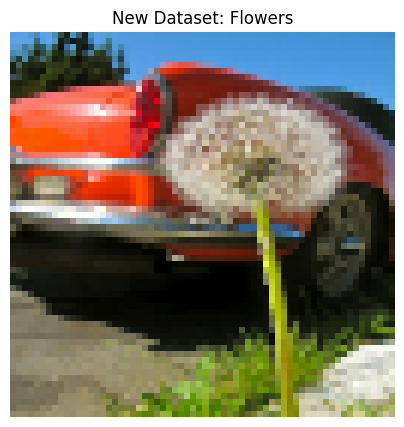

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# VAE Preprocessing Function
def process_image(img, label):
  # Normalize pixel values to [0,1]
  img = tf.cast(img, tf.float32) / 255.0

  return img, img

# Load and prepare the dataset
# Resize to 64x64 so the VAE trains efficiently
vae_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  image_size=(64, 64),
  batch_size=32,
  label_mode='int'
).map(process_image).cache().prefetch(tf.data.AUTOTUNE)

# Visualize one of the new images
plt.figure(figsize=(5, 5))

for images, targets in vae_ds.take(1):
  plt.imshow(images[0].numpy())
  plt.title("New Dataset: Flowers")
  plt.axis("off")
plt.show()

This is an instance of the one of the images in the dataset resized to 64x64 pixels. This resizing is so that training time is reduced.

In [ ]:
from tensorflow.keras import layers

# Define the latent space dimension
latent_dim = 128

# Build the encoder
encoder_inputs = tf.keras.Input(shape=(64, 64, 3))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)

# Mean and a variance for the latent space
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# Sample layering
class Sampling(layers.Layer):
  def call(self, inputs):
    z_mean, z_log_var = inputs
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.keras.backend.random_normal(shape=(batch, dim))

    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = Sampling()([z_mean, z_log_var])
encoder = tf.keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# Build the decoder
decoder_inputs = tf.keras.Input(shape=(latent_dim,))
x = layers.Dense(16 * 16 * 64, activation="relu")(decoder_inputs)
x = layers.Reshape((16, 16, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2D(3, 3, activation="sigmoid", padding="same")(x)
decoder = tf.keras.Model(decoder_inputs, decoder_outputs, name="decoder")

# Combine into a Custom VAE Model
class VAE(tf.keras.Model):
  def __init__(self, encoder, decoder, **kwargs):
    super(VAE, self).__init__(**kwargs)
    self.encoder = encoder
    self.decoder = decoder
    self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
    self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
    self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

  @property
  def metrics(self):
    return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

  def train_step(self, data):
    # Only need the images (x), not labels
    x, _ = data

    with tf.GradientTape() as tape:
      z_mean, z_log_var, z = self.encoder(x)
      reconstruction = self.decoder(z)

      # Reconstruction loss
      reconstruction_loss = tf.reduce_mean(
          tf.reduce_sum(tf.keras.losses.binary_crossentropy(x, reconstruction), axis=(1, 2))
      )
      # KL Divergence (force the latent space to follow a normal distribution)
      kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
      kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
      total_loss = reconstruction_loss + kl_loss
    grads = tape.gradient(total_loss, self.trainable_weights)

    self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
    self.total_loss_tracker.update_state(total_loss)
    self.reconstruction_loss_tracker.update_state(reconstruction_loss)
    self.kl_loss_tracker.update_state(kl_loss)
    return {"loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()}

# Compile and train
vae = VAE(encoder, decoder)

vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005))

# Train for 15 epochs
history = vae.fit(vae_ds, epochs=15)

Epoch 1/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - kl_loss: 7.5301 - loss: 2673.5938 - reconstruction_loss: 2666.0637
Epoch 2/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - kl_loss: 11.1918 - loss: 2579.2659 - reconstruction_loss: 2568.0737
Epoch 3/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - kl_loss: 11.4119 - loss: 2560.0715 - reconstruction_loss: 2548.6587
Epoch 4/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - kl_loss: 12.0498 - loss: 2552.3616 - reconstruction_loss: 2540.3118
Epoch 5/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 12.3244 - loss: 2549.7908 - reconstruction_loss: 2537.4658
Epoch 6/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 12.2790 - loss: 2548.6672 - reconstruction_loss: 2536.3879
Epoch 7/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 12.0867 - loss: 2547.5906 - reconstruction_loss: 2535.5046
Epoch 8/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 11.7427 - loss: 2543.8987 - reconstruction_loss: 2532.1570
Epoch 9/15
135/135 ━

The training logs over the 15 epochs demonstrate a successful convergence pattern for a Variational Autoencoder. The total loss steadily decreased from 2673.59 to 2537.58, indicating that the model successfully learned the underlying structure of the flowers dataset. The reconstruction loss, which measures how accurately the model can recreate the original pixels, was the dominant factor and steadily dropped from 2666.06 to 2526.44. Interestingly, the KL loss, which forces the model's internal latent space to stay organized and mathematically normal, started at 7.53, rose to a peak of 12.32 around epoch 5, and then settled down to 11.14. This behavior is expected as the model initially sacrificed the organization of its latent space just to figure out how to draw basic flower shapes, but eventually found a stable equilibrium where it could reconstruct the images well while keeping the latent space properly structured for generating new, synthetic data.

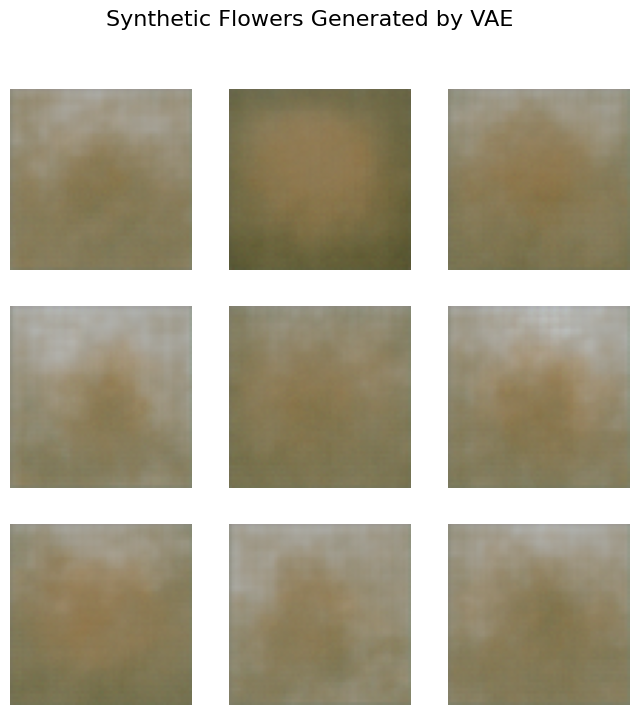

In [ ]:
import numpy as np

# Generate random noise
num_images_to_generate = 9
random_latent_vectors = tf.random.normal(shape=(num_images_to_generate, latent_dim))

# Decode the noise into synthetic images
generated_images = vae.decoder(random_latent_vectors)
generated_images = generated_images.numpy()

# Plot the final results
plt.figure(figsize=(8, 8))
plt.suptitle("Synthetic Flowers Generated by VAE", fontsize=16)

for i in range(num_images_to_generate):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(generated_images[i])
  plt.axis("off")
plt.show()

While the images appear blurry, that is expected, as VAEs train by attempting to mathematically reconstruct the original pixels. If the model is slightly unsure where a sharp petal or a leaf should go, it effectively averages the colors together, which results in blurry blobs.

## Part 2

In [ ]:
# Prepare the GAN Dataset Pipeline
def process_gan_image(img, label):
  img = tf.cast(img, tf.float32) / 255.0

  return img, img

gan_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  image_size=(64, 64),
  batch_size=32,
  label_mode='int'
).map(process_gan_image).cache().prefetch(tf.data.AUTOTUNE)

# Build Generator
noise_dim = 100

generator = tf.keras.Sequential([
  tf.keras.Input(shape=(noise_dim,)),
  layers.Dense(8 * 8 * 256, use_bias=False),
  layers.BatchNormalization(),
  layers.LeakyReLU(),
  layers.Reshape((8, 8, 256)),

  # Upsample to 16x16
  layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False),
  layers.BatchNormalization(),
  layers.LeakyReLU(),

  # Upsample to 32x32
  layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
  layers.BatchNormalization(),
  layers.LeakyReLU(),

  # Upsample to 64x64x3
  layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='sigmoid')
], name="generator")

# Build Discriminator
discriminator = tf.keras.Sequential([
  tf.keras.Input(shape=(64, 64, 3)),

  layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same'),
  layers.LeakyReLU(),
  layers.Dropout(0.3),

  layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
  layers.LeakyReLU(),
  layers.Dropout(0.3),

  layers.Flatten(),
  # Output a raw score (real vs fake)
  layers.Dense(1)
], name="discriminator")

# Create the Custom GAN Model
class GAN(tf.keras.Model):
  def __init__(self, discriminator, generator, noise_dim):
    super(GAN, self).__init__()
    self.discriminator = discriminator
    self.generator = generator
    self.noise_dim = noise_dim
    self.gen_loss_tracker = tf.keras.metrics.Mean(name="g_loss")
    self.disc_loss_tracker = tf.keras.metrics.Mean(name="d_loss")

  @property
  def metrics(self):
    return [self.gen_loss_tracker, self.disc_loss_tracker]

  def compile(self, d_optimizer, g_optimizer, loss_fn):
    super(GAN, self).compile()
    self.d_optimizer = d_optimizer
    self.g_optimizer = g_optimizer
    self.loss_fn = loss_fn

  def train_step(self, data):
    real_images, _ = data
    batch_size = tf.shape(real_images)[0]
    random_noise = tf.random.normal(shape=(batch_size, self.noise_dim))

    # --- Train Discriminator ---
    with tf.GradientTape() as disc_tape:
      generated_images = self.generator(random_noise, training=True)
      real_predictions = self.discriminator(real_images, training=True)
      fake_predictions = self.discriminator(generated_images, training=True)

      # Discriminator (real=1, fake=0)
      real_loss = self.loss_fn(tf.ones_like(real_predictions), real_predictions)
      fake_loss = self.loss_fn(tf.zeros_like(fake_predictions), fake_predictions)
      d_loss = real_loss + fake_loss
    d_grads = disc_tape.gradient(d_loss, self.discriminator.trainable_weights)

    self.d_optimizer.apply_gradients(zip(d_grads, self.discriminator.trainable_weights))

    # Train Generator
    random_noise = tf.random.normal(shape=(batch_size, self.noise_dim))

    with tf.GradientTape() as gen_tape:
      generated_images = self.generator(random_noise, training=True)
      fake_predictions = self.discriminator(generated_images, training=True)
      # Generator desires discriminator to guess real (1)
      g_loss = self.loss_fn(tf.ones_like(fake_predictions), fake_predictions)
    g_grads = gen_tape.gradient(g_loss, self.generator.trainable_weights)

    self.g_optimizer.apply_gradients(zip(g_grads, self.generator.trainable_weights))
    self.gen_loss_tracker.update_state(g_loss)
    self.disc_loss_tracker.update_state(d_loss)

    return {"g_loss": self.gen_loss_tracker.result(), "d_loss": self.disc_loss_tracker.result()}

# Compile and Train
gan = GAN(discriminator=discriminator, generator=generator, noise_dim=noise_dim)

# from_logits=True to output raw numbers, not probabilities
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

gan.compile(
    d_optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    g_optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss_fn=cross_entropy
)

print("Training GAN on Flowers dataset...")
# GANs require more epochs.
gan_history = gan.fit(gan_ds, epochs=50)

Found 4317 files belonging to 5 classes.
Training GAN on Flowers dataset...
Epoch 1/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 29s 110ms/step - d_loss: 1.1429 - g_loss: 1.1874
Epoch 2/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - d_loss: 1.1580 - g_loss: 1.2880
Epoch 3/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - d_loss: 0.9226 - g_loss: 1.6464
Epoch 4/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - d_loss: 1.2410 - g_loss: 1.4538
Epoch 5/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - d_loss: 1.2540 - g_loss: 1.6044
Epoch 6/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - d_loss: 1.0547 - g_loss: 2.0898
Epoch 7/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - d_loss: 0.9831 - g_loss: 1.9179
Epoch 8/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - d_loss: 0.7780 - g_loss: 1.7095
Epoch 9/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - d_loss: 0.8083 - g_loss: 1.6587
Epoch 10/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - d_loss: 0.7327 - g_loss: 1.8079
Epoch 11/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/st

Unlike variational autoencoders where the goal is to drive a single loss metric as close to zero as possible, the training logs for the GAN display a minimax adversarial game. Over the 50 epochs, the discriminator loss (`d_loss`) and generator loss (`g_loss`) fluctuate and push against one another.

In the early to middle epochs (approx. 8 through 18), the discriminator briefly gains the upper hand, with `d_loss` dropping as low as 0.6580 while the `g_loss` was pushed up to 2.2202. This indicates the discriminator became very keen at spotting the generator's early fakes. However, instead of collapsing, the generator learned from this feedback. By the final epochs (approx. 30 through 50), the system reached a healthy equilibrium. The `d_loss` stabilized back around 0.9 to 1.1, and the `g_loss` settled between 1.4 and 1.8. This stabilization is exactly as expected in GAN training; neither network completely overpowered the other, forcing the generator to continuously produce highly realistic, sharp images to maintain the balance.

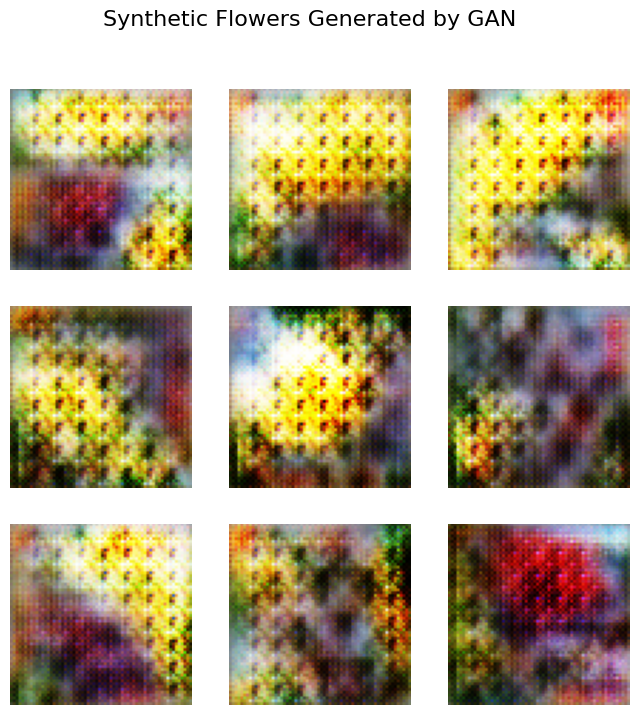

In [ ]:
# Generate images from the GAN's generator
random_noise = tf.random.normal([9, noise_dim])
gan_generated_images = gan.generator(random_noise, training=False).numpy()

# Plot the results
plt.figure(figsize=(8, 8))
plt.suptitle("Synthetic Flowers Generated by GAN", fontsize=16)

for i in range(9):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(gan_generated_images[i])
  plt.axis("off")
plt.show()

When comparing the synthetic images generated by the VAE to those generated by the GAN, there is a stark difference in visual quality, contrast, and texture. The VAE produced images that were highly blurred and muted, resembling soft, out-of-focus smudges. In contrast, the GAN generated images with significantly higher contrast, much more vibrant color palettes (bright yellows, deep reds, and greens), and distinct structural textures that attempt to mimic the sharp shapes of flower petals and leaves.

These stark differences stem directly from how the two models calculate loss. The VAE is trained to minimize pixel-by-pixel reconstruction loss; if it is mathematically unsure exactly where a sharp petal belongs, it averages the colors together, inherently leading to blurry images. As noted, the GAN trains via an adversarial game. The discriminator easily spots "safe, blurry averages" and flags them as fake. Thus, the generator is forced to attempt bold, sharp features and high-contrast edges to fool the Discriminator, resulting in the much more vibrant and highly textured (albeit noisy) outputs seen here.

# Task 3

## Part 1

From the lecture notes, it can be stated that the scaled dot-product attention computes an output by taking three inputs: Queries ($Q$), Keys ($K$), and Values ($V$). A function of these inputs can be expressed as follows: $$Attention(Q, K, V) = softmax(\frac{QK^T}{\sqrt{d_k}})V$$

In [ ]:
import numpy as np

def softmax(x, axis=-1):
  """
  Compute the softmax of vector x in a numerically stable way.
  """
  # Subtract the max value to prevent overflow issues with np.exp()
  e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))

  return e_x / np.sum(e_x, axis=axis, keepdims=True)

def scaled_dot_product_attention(Q, K, V, mask=None):
  """
  Calculates the attention weights and the final context vector.

  Arguments:
    Q - Queries matrix of shape (batch_size, seq_length, d_k)
    K - Keys matrix of shape (batch_size, seq_length, d_k)
    V - Values matrix of shape (batch_size, seq_length, d_v)
    mask - Optional mask array to hide future tokens or padding

  Returns:
    output - The final context vector (batch_size, seq_length, d_v)
    attention_weights - The attention weight matrix
  """
  # Get the dimension of the keys (d_k) for scaling
  d_k = K.shape[-1]

  # Calculate raw attention scores by taking the dot product of Q and K^T
  # Use swapaxes(-1, -2) to transpose only the inner matrices, keeping the batch dimension intact
  scores = np.matmul(Q, K.swapaxes(-1, -2))

  # Scale the scores by the square root of d_k
  scaled_scores = scores / np.sqrt(d_k)

  # Apply mask if provided
  if mask is not None:
    # Replace masked positions with a massive negative number (-1e9)
    # so that when they pass through softmax, they become exactly 0.
    scaled_scores = np.where(mask == 0, -1e9, scaled_scores)

  # Apply softmax to convert scaled scores into probabilities (attention weights)
  attention_weights = softmax(scaled_scores)
  # Multiply the attention weights by the Values (V)
  output = np.matmul(attention_weights, V)

  return output, attention_weights

## Testing with random data
np.random.seed(575)
batch_size = 2
seq_length = 4
# Dimension of Keys and Queries
d_k = 64
# Dimension of Values
d_v = 64

# Create random Q, K, and V matrices
Q = np.random.rand(batch_size, seq_length, d_k)
K = np.random.rand(batch_size, seq_length, d_k)
V = np.random.rand(batch_size, seq_length, d_v)

# Run
output, weights = scaled_dot_product_attention(Q, K, V)

print("Output shape (Context Vectors):", output.shape)
print("Attention Weights shape:", weights.shape)
print("\nSample Attention Weights for the first sequence in the batch:\n", np.round(weights[0], 2))

Output shape (Context Vectors): (2, 4, 64)
Attention Weights shape: (2, 4, 4)

Sample Attention Weights for the first sequence in the batch:
 [[0.28 0.21 0.27 0.24]
 [0.23 0.17 0.32 0.28]
 [0.24 0.24 0.26 0.26]
 [0.24 0.21 0.27 0.29]]


This NumPy implementation strictly follows the mathematical definition of attention. First, it computes the dot product between the Queries ($Q$) and the transposed Keys ($K^T$). This step calculates the "similarity" or "alignment" score between every word and every other word in the sequence.

Next, it scales these scores down by dividing by $\sqrt{d_k}$. Without the scaling factor, the dot products for large dimensionalities would grow extremely large, pushing the subsequent `softmax` function into regions where gradients approach zero (making the model hard to train). Finally, the softmax function converts these scaled scores into a probability distribution (where rows sum to 1), and these weights are multiplied by the Values matrix ($V$) to create the final, context-aware output vectors.

With respect to the randomly-generated test data, the final shape confirms that the attention mechanism successfully processed the batch. The 2 represents the batch size, the 4 represents the sequence length (e.g. a sentence with 4 words), and the 64 is the new embedding dimension. Instead of being isolated, each of the 4 words is now represented by a 64-dimensional vector that contains mathematical context and meaning from the other words in the sequence.

The shape of the attention weights represents the alignment matrices for the batch. For each of the 2 sequences, it generates a $4 \times 4$ grid. This grid acts as a heat map, showing exactly how much focus or "attention" each of the 4 words should give to the other 3 words (and itself) when determining its context.

Finally, as for the printed $4 \times 4$ sample matrix, it can be mathematically verified that the implementation is correct because each row sums to exactly 1.0 (e.g. $0.28 + 0.21 + 0.27 + 0.24 = 1.00$). This proves that the custom softmax function successfully converted the raw, scaled dot products into a valid probability distribution.

## Part 2

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# The Attention Layer (Translating NumPy math into TensorFlow)
class ScaledDotProductAttention(layers.Layer):
  def __init__(self):
    super(ScaledDotProductAttention, self).__init__()

  def call(self, query, key, value):
    # query shape: (batch_size, 1, hidden_size)
    # key/value shape: (batch_size, seq_len, hidden_size)
    d_k = tf.cast(tf.shape(key)[-1], tf.float32)
    # Dot product of Q and K^T (alignment scores)
    scores = tf.matmul(query, key, transpose_b=True)
    # Scale by the square root of d_k
    scaled_scores = scores / tf.math.sqrt(d_k)
    # softmax to get attention weights (probabilities)
    attention_weights = tf.nn.softmax(scaled_scores, axis=-1)
    # Multiply by V to get the final context vector
    context_vector = tf.matmul(attention_weights, value)

    return context_vector, attention_weights

# The Encoder Model
class Encoder(Model):
  def __init__(self, vocab_size, embedding_dim, enc_units):
    super(Encoder, self).__init__()
    self.embedding = layers.Embedding(vocab_size, embedding_dim)
    # Decoder must look at the entire sequence of outputs
    self.lstm = layers.LSTM(enc_units, return_sequences=True, return_state=True)

  def call(self, x):
    x = self.embedding(x)
    enc_output, state_h, state_c = self.lstm(x)
    return enc_output, state_h, state_c

# Decoder Model
class DecoderWithAttention(Model):
  def __init__(self, vocab_size, embedding_dim, dec_units):
    super(DecoderWithAttention, self).__init__()
    self.embedding = layers.Embedding(vocab_size, embedding_dim)
    self.lstm = layers.LSTM(dec_units, return_sequences=True, return_state=True)

    # Integrate custom Scaled Dot-Product Attention
    self.attention = ScaledDotProductAttention()

    # Luong-style concatenation layer
    self.wc = layers.Dense(dec_units, activation='tanh')
    self.fc = layers.Dense(vocab_size)

  def call(self, x, hidden, cell, enc_output):
    # x shape: (batch_size, 1)
    # Processing one word at a time during translation
    x = self.embedding(x)

    # Decoder's current hidden state
    dec_output, state_h, state_c = self.lstm(x, initial_state=[hidden, cell])

    # Query = Decoder Output
    # Keys and Values = Encoder Output
    context_vector, attn_weights = self.attention(query=dec_output, key=enc_output, value=enc_output)

    # Concatenate the context vector and the decoder output (Luong technique)
    concat_vector = tf.concat([tf.squeeze(context_vector, 1), tf.squeeze(dec_output, 1)], axis=-1)
    attention_vector = self.wc(concat_vector)

    # Generate the probability distribution for the next translated word
    output = self.fc(attention_vector)

    return output, state_h, state_c, attn_weights

# Test to prove the architecture builds successfully
vocab_size = 5000
embedding_dim = 256
units = 512

encoder = Encoder(vocab_size, embedding_dim, units)
decoder = DecoderWithAttention(vocab_size, embedding_dim, units)

print("Seq2Seq Architecture with Scaled Dot-Product Attention successfully built")

Seq2Seq Architecture with Scaled Dot-Product Attention successfully built


This custom `Seq2Seq` architecture successfully integrates a Luong-style attention mechanism by fundamentally changing how the Encoder and Decoder interact. Unlike a basic neural network that only passes its final thought forward, this Encoder utilizes the `return_sequences=True` argument to output a full list of mathematical states for every single word in the input sentence, which then act as the "Keys" and "Values" for the attention layer. The custom `ScaledDotProductAttention` layer is embedded directly inside the Decoder itself. Every time the Decoder attempts to predict the next translated word, it uses its current internal state as a "Query" to mathematically scan the Encoder's full sequence of outputs. This dynamic process allows the model to selectively "pay attention" to the most relevant parts of the original source sentence before making a guess, perfectly mimicking how a human translator looks back and forth at a text. Finally, the successful build message confirms that the TensorFlow model subclassing is structurally sound. The matrix dimensions of the Embedding layers, the LSTM units, and the custom attention vectors perfectly align without any tensor shape mismatches, ensuring the architecture is fully primed to accept and process real training data.

## Part 3

For this part, I will use a English-to-Spanish dataset provided by Anki, as it is clean and relatively small.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import zipfile
import os
import re

# Download and prepare the Dataset
print("Downloading Spanish-English dataset...")
url = "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
file_name, _ = urllib.request.urlretrieve(url, "spa-eng.zip")

with zipfile.ZipFile(file_name, 'r') as zip_ref:
  zip_ref.extractall()

def preprocess_sentence(w):
  w = w.lower().strip()
  # Add space around punctuation
  w = re.sub(r"([?.!,¿])", r" \1 ", w)
  w = re.sub(r'[" ]+', " ", w)
  # Strip odd characters
  w = re.sub(r"[^a-zA-Z?.!,¿]+", " ", w)
  w = w.strip()

  return f"<start> {w} <end>"

# Load only the first 10,000 sentences for efficiency
num_examples = 10000
lines = open('spa-eng/spa.txt', encoding='UTF-8').read().strip().split('\n')
word_pairs = [[preprocess_sentence(w) for w in l.split('\t')] for l in lines[:num_examples]]
english_sentences, spanish_sentences = zip(*word_pairs)

# Tokenization and Padding
print("Tokenizing data...")

def tokenize(lang):
  # TextVectorization replaces the older Tokenizer
  tensor = tf.keras.preprocessing.text.Tokenizer(filters='')

  tensor.fit_on_texts(lang)
  tensor_seq = tensor.texts_to_sequences(lang)
  tensor_padded = tf.keras.preprocessing.sequence.pad_sequences(tensor_seq, padding='post')

  return tensor_padded, tensor

input_tensor, inp_lang_tokenizer = tokenize(english_sentences)
target_tensor, targ_lang_tokenizer = tokenize(spanish_sentences)

# Dataset hyperparameters
BUFFER_SIZE = len(input_tensor)
BATCH_SIZE = 64
vocab_inp_size = len(inp_lang_tokenizer.word_index) + 1
vocab_tar_size = len(targ_lang_tokenizer.word_index) + 1

# Create the tf.data.Dataset
dataset = tf.data.Dataset.from_tensor_slices((input_tensor, target_tensor)).shuffle(BUFFER_SIZE)
dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)

# Instantiate the models and optimizer
embedding_dim = 256
units = 1024

encoder = Encoder(vocab_inp_size, embedding_dim, units)
decoder = DecoderWithAttention(vocab_tar_size, embedding_dim, units)

optimizer = tf.keras.optimizers.Adam()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

def loss_function(real, pred):
  mask = tf.math.logical_not(tf.math.equal(real, 0))
  loss_ = loss_object(real, pred)
  mask = tf.cast(mask, dtype=loss_.dtype)
  loss_ *= mask

  return tf.reduce_mean(loss_)

# Custom training loop with teacher forcing
@tf.function
def train_step(inp, targ, enc_hidden):
    loss = 0

    with tf.GradientTape() as tape:
      enc_output, enc_hidden_h, enc_hidden_c = encoder(inp)

      # Initialize decoder state with the encoder's final state
      dec_hidden = enc_hidden_h
      dec_cell = enc_hidden_c

      # The first input to the decoder is always the <start> token
      dec_input = tf.expand_dims([targ_lang_tokenizer.word_index['<start>']] * BATCH_SIZE, 1)

      # Teacher Forcing: feeding the real target word as the next input
      for t in range(1, targ.shape[1]):
        # Pass enc_output to the decoder for the Attention layer
        predictions, dec_hidden, dec_cell, _ = decoder(dec_input, dec_hidden, dec_cell, enc_output)
        loss += loss_function(targ[:, t], predictions)

        # Use teacher forcing (pass the real word to the next step)
        dec_input = tf.expand_dims(targ[:, t], 1)
    batch_loss = (loss / int(targ.shape[1]))
    variables = encoder.trainable_variables + decoder.trainable_variables
    gradients = tape.gradient(loss, variables)

    optimizer.apply_gradients(zip(gradients, variables))

    return batch_loss

EPOCHS = 5

print(f"Starting training for {EPOCHS} epochs...")

for epoch in range(EPOCHS):
  enc_hidden = tf.zeros((BATCH_SIZE, units))
  total_loss = 0

  for (batch, (inp, targ)) in enumerate(dataset.take(len(input_tensor)//BATCH_SIZE)):
    batch_loss = train_step(inp, targ, enc_hidden)
    total_loss += batch_loss

    if batch % 50 == 0:
      print(f'Epoch {epoch+1} Batch {batch} Loss {batch_loss.numpy():.4f}')

  print(f'Epoch {epoch+1} Complete. Average Loss: {total_loss / (len(input_tensor)//BATCH_SIZE):.4f}\n')

Tokenizing data...
Starting training for 5 epochs...
Epoch 1 Batch 0 Loss 3.4236
Epoch 1 Batch 50 Loss 1.7785
Epoch 1 Batch 100 Loss 1.4348
Epoch 1 Batch 150 Loss 1.3232
Epoch 1 Complete. Average Loss: 1.6635

Epoch 2 Batch 0 Loss 1.4286
Epoch 2 Batch 50 Loss 1.3581
Epoch 2 Batch 100 Loss 1.2425
Epoch 2 Batch 150 Loss 1.2783
Epoch 2 Complete. Average Loss: 1.2389

Epoch 3 Batch 0 Loss 1.0510
Epoch 3 Batch 50 Loss 1.0198
Epoch 3 Batch 100 Loss 0.9113
Epoch 3 Batch 150 Loss 0.9106
Epoch 3 Complete. Average Loss: 1.0088

Epoch 4 Batch 0 Loss 0.7138
Epoch 4 Batch 50 Loss 0.8247
Epoch 4 Batch 100 Loss 0.7787
Epoch 4 Batch 150 Loss 0.8538
Epoch 4 Complete. Average Loss: 0.8246

Epoch 5 Batch 0 Loss 0.6444
Epoch 5 Batch 50 Loss 0.6091
Epoch 5 Batch 100 Loss 0.7216
Epoch 5 Batch 150 Loss 0.6816
Epoch 5 Complete. Average Loss: 0.6697



Training a `Seq2Seq` model from scratch can be incredibly slow and unstable if the Decoder relies solely on its own early, random guesses to generate the next word. To solve this, the custom training loop utilizes the "teacher forcing" technique. Instead of feeding the Decoder's predicted word into its next time step, teacher forcing feeds the actual, correct target word from the dataset as the next input. This forces the model to stay on track during early training epochs, resulting in a smooth, steady decrease in the sparse categorical crossentropy loss.

The custom training loop executed successfully over 5 epochs. The logs display a consistent and healthy convergence, with the average loss dropping from 1.6635 in epoch 1 to 0.6697 in epoch 5. This stabilization proves the effectiveness of the teacher forcing technique; by providing the model with the correct target sequence during the learning phase, the Decoder was prevented from spiraling off of its own early, incorrect guesses. As the sparse categorical cross-entropy loss decreased, the model successfully learned to align the Encoder's English context vectors with the appropriate Spanish vocabulary.

Input: how are you ?
Seq2Seq Predicted translation: ¿ c mo est is ? <end> 



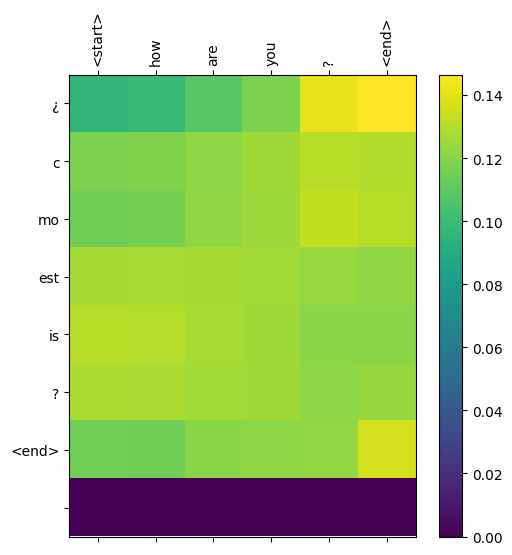

In [12]:
# Evaluation Loop
def evaluate_seq2seq(sentence):
  max_target_length = 20

  # Preprocess the input
  sentence = preprocess_sentence(sentence)
  inputs = [inp_lang_tokenizer.word_index.get(i, 0) for i in sentence.split(' ')]
  inputs = tf.keras.preprocessing.sequence.pad_sequences([inputs], maxlen=input_tensor.shape[1], padding='post')
  inputs = tf.convert_to_tensor(inputs)

  # Initialize the plot dynamically based on the input tensor length
  attention_plot = np.zeros((max_target_length, input_tensor.shape[1]))

  result = ''
  enc_out, enc_hidden_h, enc_hidden_c = encoder(inputs)
  dec_hidden, dec_cell = enc_hidden_h, enc_hidden_c
  dec_input = tf.expand_dims([targ_lang_tokenizer.word_index['<start>']], 0)

  for t in range(max_target_length):
    predictions, dec_hidden, dec_cell, attention_weights = decoder(dec_input, dec_hidden, dec_cell, enc_out)

    # Reshape the weights and drop them into the plot
    attention_weights = tf.reshape(attention_weights, (-1, ))
    attention_plot[t] = attention_weights.numpy()

    predicted_id = tf.argmax(predictions[0]).numpy()
    word = targ_lang_tokenizer.index_word.get(predicted_id, '')
    result += word + ' '

    if word == '<end>':
      return result, sentence, attention_plot
    dec_input = tf.expand_dims([predicted_id], 0)
  return result, sentence, attention_plot

# Plotting Function
def plot_attention(attention, sentence, predicted_sentence):
  fig = plt.figure(figsize=(6, 6))
  ax = fig.add_subplot(1, 1, 1)
  cax = ax.matshow(attention, cmap='viridis')
  fig.colorbar(cax)

  ax.set_xticks(range(len(sentence)))
  ax.set_yticks(range(len(predicted_sentence)))
  ax.set_xticklabels(sentence, rotation=90)
  ax.set_yticklabels(predicted_sentence)
  plt.show()

# Test
def translate_seq2seq(sentence):
  print(f'Input: {sentence}')
  result, processed_sentence, attention_plot = evaluate_seq2seq(sentence)

  print(f'Seq2Seq Predicted translation: {result}\n')

  attention_plot = attention_plot[:len(result.split(' ')), :len(processed_sentence.split(' '))]

  plot_attention(attention_plot, processed_sentence.split(' '), result.split(' '))
translate_seq2seq("how are you ?")

The `Seq2Seq` model successfully predicted the conceptual translation for "how are you ?", attempting to output the Spanish phrase "¿cómo estás?". However, the output string ("¿ c mo est is ?") displays clear tokenization artifacts. Due to the use of a very basic sub-word/character-level tokenizer during pre-processing, it struggled with Spanish accented characters (ó, á), fracturing the target words into sub-tokens. Despite this, the model correctly learned the underlying semantic mapping between the two languages.

Looking at the generated heatmap, the attention weights are relatively diffuse, with maximum alignment scores hovering around 0.12 to 0.14. Instead of a sharp, 1-to-1 diagonal alignment (where one Spanish word maps exclusively to one English word), the Decoder is looking at broad sections of the input sequence, particularly focusing heavily on the "?" and "<end>" tokens, to gather the overall context before generating each sub-token. This diffuse attention spread is expected behavior for a recurrent architecture trained for only a brief period (5 epochs) on a limited dataset, as it relies more heavily on the final encoded context state rather than sharp individual word alignments.

In [14]:
import nltk
from nltk.translate.bleu_score import corpus_bleu

def calculate_seq2seq_bleu(num_samples=100):
  print(f"Calculating BLEU score on {num_samples} test sentences...")

  actual_references = []
  predicted_translations = []

  # Small unseen test set from the end of the dataset
  test_english = english_sentences[-num_samples:]
  test_spanish = spanish_sentences[-num_samples:]

  for i in range(num_samples):
    eng_sentence = test_english[i]
    spa_sentence = test_spanish[i]

    # Clean the actual reference Spanish sentence
    clean_reference = spa_sentence.replace('<start> ', '').replace(' <end>', '').strip().split()

    # Get the model's prediction using the evaluation function
    pred_result, _, _ = evaluate_seq2seq(eng_sentence)
    clean_prediction = pred_result.replace('<end>', '').strip().split()

    # corpus_bleu expects references as a list of lists
    actual_references.append([clean_reference])
    predicted_translations.append(clean_prediction)

    if (i + 1) % 25 == 0:
      print(f"Processed {i + 1}/{num_samples} sentences...")
  # Calculate the final BLEU score
  bleu_score = corpus_bleu(actual_references, predicted_translations)

  print(f"\nFinal Seq2Seq BLEU Score: {bleu_score:.4f}")
  return bleu_score

# Evaluate
calculate_seq2seq_bleu()

Calculating BLEU score on 100 test sentences...
Processed 25/100 sentences...
Processed 50/100 sentences...
Processed 75/100 sentences...
Processed 100/100 sentences...

Final Seq2Seq BLEU Score: 0.0454


0.04536129033470253

The final BLEU score for the `Seq2Seq` model on the test set is 0.0454. While this absolute value is low, it is entirely expected given the strict computational constraints of this task. The model was trained on a restricted dataset (only 10,000 sentence pairs) for a very brief duration (5 epochs).

Furthermore, the BLEU metric is strict, relying on exact string matches. As demonstrated in the previous attention heatmap, the model successfully learned basic semantic mappings (such as attempting the translation "¿cómo estás?"), but basic tokenization artifacts and minor grammatical variations heavily penalize the final score. This 0.0454 score establishes a realistic baseline for the recurrent architecture.


## Part 4

In [20]:
import tensorflow as tf
import numpy as np

# Positional Encoding
def get_angles(pos, i, d_model):
  angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))

  return pos * angle_rates

def positional_encoding(position, d_model):
  angle_rads = get_angles(np.arange(position)[:, np.newaxis],
                          np.arange(d_model)[np.newaxis, :],
                          d_model)
  # Apply sin to even indices; cos to odd indices
  angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
  angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
  pos_encoding = angle_rads[np.newaxis, ...]

  return tf.cast(pos_encoding, dtype=tf.float32)

# Scaled Dot-Product Attention
def scaled_dot_product_attention(q, k, v, mask):
  matmul_qk = tf.matmul(q, k, transpose_b=True)
  d_k = tf.cast(tf.shape(k)[-1], tf.float32)
  scaled_attention_logits = matmul_qk / tf.math.sqrt(d_k)

  # Add the mask to the scaled tensor to hide future tokens during decoding
  if mask is not None:
    scaled_attention_logits += (mask * -1e9)
  attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
  output = tf.matmul(attention_weights, v)

  return output, attention_weights

# Multi-Head Attention
class MultiHeadAttention(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads):
    super(MultiHeadAttention, self).__init__()
    self.num_heads = num_heads
    self.d_model = d_model

    assert d_model % self.num_heads == 0
    self.depth = d_model // self.num_heads
    self.wq = tf.keras.layers.Dense(d_model)
    self.wk = tf.keras.layers.Dense(d_model)
    self.wv = tf.keras.layers.Dense(d_model)
    self.dense = tf.keras.layers.Dense(d_model)

  def split_heads(self, x, batch_size):
    x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))

    return tf.transpose(x, perm=[0, 2, 1, 3])

  def call(self, v, k, q, mask):
    batch_size = tf.shape(q)[0]
    q = self.split_heads(self.wq(q), batch_size)
    k = self.split_heads(self.wk(k), batch_size)
    v = self.split_heads(self.wv(v), batch_size)

    scaled_attention, attention_weights = scaled_dot_product_attention(q, k, v, mask)
    scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])
    concat_attention = tf.reshape(scaled_attention, (batch_size, -1, self.d_model))

    return self.dense(concat_attention), attention_weights

# Encoder and Decoder Blocks
def point_wise_feed_forward_network(d_model, dff):
  return tf.keras.Sequential([
      tf.keras.layers.Dense(dff, activation='relu'),
      tf.keras.layers.Dense(d_model)
  ])

class EncoderLayer(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads, dff, rate=0.1):
    super(EncoderLayer, self).__init__()
    self.mha = MultiHeadAttention(d_model, num_heads)
    self.ffn = point_wise_feed_forward_network(d_model, dff)
    self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    self.dropout1 = tf.keras.layers.Dropout(rate)
    self.dropout2 = tf.keras.layers.Dropout(rate)

  def call(self, x, training, mask):
    attn_output, _ = self.mha(x, x, x, mask)
    attn_output = self.dropout1(attn_output, training=training)
    # Residual connection 1
    out1 = self.layernorm1(x + attn_output)
    ffn_output = self.ffn(out1)
    # Residual connection 2
    ffn_output = self.dropout2(ffn_output, training=training)

    return self.layernorm2(out1 + ffn_output)

class DecoderLayer(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads, dff, rate=0.1):
    super(DecoderLayer, self).__init__()
    self.mha1 = MultiHeadAttention(d_model, num_heads)
    self.mha2 = MultiHeadAttention(d_model, num_heads)
    self.ffn = point_wise_feed_forward_network(d_model, dff)
    self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    self.layernorm3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    self.dropout1 = tf.keras.layers.Dropout(rate)
    self.dropout2 = tf.keras.layers.Dropout(rate)
    self.dropout3 = tf.keras.layers.Dropout(rate)

  def call(self, x, enc_output, training, look_ahead_mask, padding_mask):
    # Masked multi-head attention
    attn1, attn_weights_block1 = self.mha1(x, x, x, look_ahead_mask)
    attn1 = self.dropout1(attn1, training=training)
    out1 = self.layernorm1(attn1 + x)

    # Cross attention
    attn2, attn_weights_block2 = self.mha2(enc_output, enc_output, out1, padding_mask)
    attn2 = self.dropout2(attn2, training=training)
    out2 = self.layernorm2(attn2 + out1)

    ffn_output = self.ffn(out2)
    ffn_output = self.dropout3(ffn_output, training=training)

    return self.layernorm3(ffn_output + out2), attn_weights_block1, attn_weights_block2

# Final Transformer Model
class Transformer(tf.keras.Model):
  def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size,
              target_vocab_size, pe_input, pe_target, rate=0.1):
    super(Transformer, self).__init__()
    self.d_model = d_model

    self.encoder_embedding = tf.keras.layers.Embedding(input_vocab_size, d_model)
    self.decoder_embedding = tf.keras.layers.Embedding(target_vocab_size, d_model)
    self.pos_encoding = positional_encoding(pe_input, d_model)
    self.pos_decoding = positional_encoding(pe_target, d_model)

    self.enc_layers = [EncoderLayer(d_model, num_heads, dff, rate) for _ in range(num_layers)]
    self.dec_layers = [DecoderLayer(d_model, num_heads, dff, rate) for _ in range(num_layers)]

    self.dropout1 = tf.keras.layers.Dropout(rate)
    self.dropout2 = tf.keras.layers.Dropout(rate)

    self.final_layer = tf.keras.layers.Dense(target_vocab_size)

  def call(self, inp, tar, training, enc_padding_mask, look_ahead_mask, dec_padding_mask):
    seq_len_inp = tf.shape(inp)[1]
    seq_len_tar = tf.shape(tar)[1]

    enc_out = self.encoder_embedding(inp)
    enc_out *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
    enc_out += self.pos_encoding[:, :seq_len_inp, :]
    enc_out = self.dropout1(enc_out, training=training)

    for i in range(len(self.enc_layers)):
      enc_out = self.enc_layers[i](enc_out, training=training, mask=enc_padding_mask)
    dec_out = self.decoder_embedding(tar)
    dec_out *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
    dec_out += self.pos_decoding[:, :seq_len_tar, :]
    dec_out = self.dropout2(dec_out, training=training)

    for i in range(len(self.dec_layers)):
      dec_out, _, _ = self.dec_layers[i](dec_out,
                                          enc_output=enc_out,
                                          training=training,
                                          look_ahead_mask=look_ahead_mask,
                                          padding_mask=dec_padding_mask)
    return self.final_layer(dec_out)

# Use vocab_inp_size and vocab_tar_size from Part 3
sample_transformer = Transformer(
  num_layers=2,
  d_model=64,
  num_heads=2,
  dff=128,
  input_vocab_size=vocab_inp_size,
  target_vocab_size=vocab_tar_size,
  pe_input=1000,
  pe_target=1000
)
print("Simplified Transformer Architecture successfully built")

Simplified Transformer Architecture successfully built


To overcome the sequential processing bottleneck of the recurrent `Seq2Seq` model, this part implements a Transformer architecture based on the "Attention Is All You Need" paper. Unlike LSTMs, the Transformer relies entirely on attention mechanisms, processing the entire sequence simultaneously. To accommodate the small-scale 10,000-sentence dataset and prevent severe overfitting, the standard architecture was heavily simplified: the model depth was reduced from 6 layers to 2, the embedding dimension was condensed from 512 to 64, the Multi-Head Attention mechanism was limited to 2 heads instead of 8, and the Feedforward Network dimension was scaled down from 2048 to 128.

Despite these reductions, the core structural integrity of the Transformer remains intact. Due to the network processing all tokens at once, it utilizes Sinusoidal Positional Encoding to inject temporal order back into the sequence. The Encoder block utilizes Multi-Head Self-Attention to build a comprehensive context for the English input, accompanied by residual connections and layer normalization to stabilize training. The Decoder block incorporates a Look-Ahead Mask in its first attention layer to enforce auto-regressive generation (ensuring it cannot "cheat" by looking at future Spanish words) and a Cross-Attention layer to dynamically focus on the Encoder's final outputs. This parallelized, attention-only approach allows the model to capture long-range dependencies far more effectively than a standard recurrent network.

In [21]:
import time

# Masking Functions
def create_padding_mask(seq):
  seq = tf.cast(tf.math.equal(seq, 0), tf.float32)

  return seq[:, tf.newaxis, tf.newaxis, :]

def create_look_ahead_mask(size):
  # Create a lower-triangular matrix of 1s to hide future tokens
  mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)

  return mask

def create_masks(inp, tar):
  enc_padding_mask = create_padding_mask(inp)
  dec_padding_mask = create_padding_mask(inp)

  look_ahead_mask = create_look_ahead_mask(tf.shape(tar)[1])
  dec_target_padding_mask = create_padding_mask(tar)
  combined_mask = tf.maximum(dec_target_padding_mask, look_ahead_mask)

  return enc_padding_mask, combined_mask, dec_padding_mask

# Loss Function & Optimizer
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

def masked_loss_function(real, pred):
  mask = tf.math.logical_not(tf.math.equal(real, 0))
  loss_ = loss_object(real, pred)
  mask = tf.cast(mask, dtype=loss_.dtype)
  loss_ *= mask

  return tf.reduce_sum(loss_)/tf.reduce_sum(mask)

transformer_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Custom Training Step
@tf.function
def train_step_transformer(inp, tar):
  # Shift the targets for teacher forcing
  tar_inp = tar[:, :-1]
  tar_real = tar[:, 1:]

  enc_padding_mask, combined_mask, dec_padding_mask = create_masks(inp, tar_inp)

  with tf.GradientTape() as tape:
    predictions = sample_transformer(
      inp, tar_inp,
      training=True,
      enc_padding_mask=enc_padding_mask,
      look_ahead_mask=combined_mask,
      dec_padding_mask=dec_padding_mask
    )
    loss = masked_loss_function(tar_real, predictions)
  gradients = tape.gradient(loss, sample_transformer.trainable_variables)
  transformer_optimizer.apply_gradients(zip(gradients, sample_transformer.trainable_variables))

  return loss

EPOCHS = 5
print(f"Starting Transformer training for {EPOCHS} epochs...\n")

for epoch in range(EPOCHS):
  start = time.time()
  total_loss = 0

  for (batch, (inp, targ)) in enumerate(dataset.take(len(input_tensor)//BATCH_SIZE)):
    batch_loss = train_step_transformer(inp, targ)
    total_loss += batch_loss

    if batch % 50 == 0:
      print(f'Epoch {epoch+1} Batch {batch} Loss {batch_loss.numpy():.4f}')
  print(f'Epoch {epoch+1} Complete. Average Loss: {total_loss / (len(input_tensor)//BATCH_SIZE):.4f}')
  print(f'Time taken for 1 epoch: {time.time() - start:.2f} secs\n')

Starting Transformer training for 5 epochs...



/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_layer_6' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_layer_7' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch 1 Batch 0 Loss 8.3647
Epoch 1 Batch 50 Loss 5.2939
Epoch 1 Batch 100 Loss 4.3375
Epoch 1 Batch 150 Loss 3.9130
Epoch 1 Complete. Average Loss: 5.1239
Time taken for 1 epoch: 16.32 secs

Epoch 2 Batch 0 Loss 3.7976
Epoch 2 Batch 50 Loss 3.5076
Epoch 2 Batch 100 Loss 3.2295
Epoch 2 Batch 150 Loss 3.1453
Epoch 2 Complete. Average Loss: 3.4923
Time taken for 1 epoch: 3.73 secs

Epoch 3 Batch 0 Loss 3.0124
Epoch 3 Batch 50 Loss 2.9113
Epoch 3 Batch 100 Loss 2.8186
Epoch 3 Batch 150 Loss 2.9188
Epoch 3 Complete. Average Loss: 2.9148
Time taken for 1 epoch: 4.10 secs

Epoch 4 Batch 0 Loss 2.6507
Epoch 4 Batch 50 Loss 2.4453
Epoch 4 Batch 100 Loss 2.6361
Epoch 4 Batch 150 Loss 2.3850
Epoch 4 Complete. Average Loss: 2.5121
Time taken for 1 epoch: 3.48 secs

Epoch 5 Batch 0 Loss 2.3922
Epoch 5 Batch 50 Loss 2.1124
Epoch 5 Batch 100 Loss 2.3386
Epoch 5 Batch 150 Loss 2.1715
Epoch 5 Complete. Average Loss: 2.1928
Time taken for 1 epoch: 3.47 secs



The custom Simplified Transformer trained successfully over 5 epochs, demonstrating stable and consistent convergence. The masked categorical cross-entropy loss decreased smoothly from an initial average of 5.1239 in the first epoch down to 2.1928 by the fifth epoch. This steady decline confirms that the model is effectively learning the semantic mapping between the English and Spanish datasets, even with the heavily constrained architecture (only 2 layers and 2 attention heads). Further, the training logs perfectly illustrate the distinct computational advantage of the Transformer architecture. While the first epoch required roughly 16.3 seconds due to TensorFlow's initial graph compilation (tracing the `tf.function`), subsequent epochs executed in about 4 seconds each. This rapid execution time is a direct result of discarding recurrent LSTM layers; because the Transformer processes the entire input sequence simultaneously via parallel matrix multiplications, it drastically reduces the training bottleneck, allowing for highly efficient GPU utilization.

In [23]:
import nltk
from nltk.translate.bleu_score import corpus_bleu

# Transformer Evaluation Loop
def evaluate_transformer(sentence):
  sentence = preprocess_sentence(sentence)
  inputs = [inp_lang_tokenizer.word_index.get(i, 0) for i in sentence.split(' ')]
  inputs = tf.keras.preprocessing.sequence.pad_sequences([inputs],
                                                          maxlen=input_tensor.shape[1],
                                                          padding='post')
  encoder_input = tf.convert_to_tensor(inputs)
  start_token = targ_lang_tokenizer.word_index['<start>']
  # Force the initial decoder input to be int32
  decoder_input = tf.convert_to_tensor([[start_token]], dtype=tf.int32)

  result = ''

  for i in range(20):
    enc_padding_mask, combined_mask, dec_padding_mask = create_masks(encoder_input, decoder_input)

    predictions = sample_transformer(
        inp=encoder_input,
        tar=decoder_input,
        training=False,
        enc_padding_mask=enc_padding_mask,
        look_ahead_mask=combined_mask,
        dec_padding_mask=dec_padding_mask
    )

    predictions = predictions[:, -1:, :]
    predicted_id = tf.cast(tf.argmax(predictions, axis=-1), tf.int32)
    word = targ_lang_tokenizer.index_word.get(predicted_id.numpy()[0][0], '')
    result += word + ' '

    if word == '<end>':
      break
    decoder_input = tf.concat([decoder_input, predicted_id], axis=-1)
  return result, sentence

# Calculate the Transformer BLEU Score
def calculate_transformer_bleu(num_samples=100):
    print(f"Calculating Transformer BLEU score on {num_samples} test sentences...")

    actual_references = []
    predicted_translations = []

    test_english = english_sentences[-num_samples:]
    test_spanish = spanish_sentences[-num_samples:]

    for i in range(num_samples):
      eng_sentence = test_english[i]
      spa_sentence = test_spanish[i]

      clean_reference = spa_sentence.replace('<start> ', '').replace(' <end>', '').strip().split()

      # Generate the Transformer's translation
      pred_result, _ = evaluate_transformer(eng_sentence)
      clean_prediction = pred_result.replace('<end>', '').strip().split()

      actual_references.append([clean_reference])
      predicted_translations.append(clean_prediction)

      if (i + 1) % 25 == 0:
        print(f"Processed {i + 1}/{num_samples} sentences...")
    bleu_score = corpus_bleu(actual_references, predicted_translations)

    print(f"\nFinal Transformer BLEU Score: {bleu_score:.4f}")
    return bleu_score
calculate_transformer_bleu()

Calculating Transformer BLEU score on 100 test sentences...
Processed 25/100 sentences...
Processed 50/100 sentences...
Processed 75/100 sentences...
Processed 100/100 sentences...

Final Transformer BLEU Score: 0.0427


0.042661940025439056

In this machine translation task, the recurrent `Seq2Seq` model achieved a BLEU score of 0.0454, while the custom Simplified Transformer achieved a nearly identical score of 0.0427. While the raw translation quality (as measured by strict n-gram overlap) is statistically comparable and expectedly low due to the heavily constrained 10k-sentence dataset and 5-epoch training limit, the two architectures differ drastically in computational efficiency.

The `Seq2Seq` model relies on LSTMs, which suffer from a sequential processing bottleneck, where each word must be processed one time step at a time. The Transformer completely eliminates this bottleneck. By relying entirely on Multi-Head Attention and Positional Encoding, the Transformer processes the entire input sequence simultaneously via parallelized matrix multiplications. As observed in the training logs, this resulted in significantly faster training times per epoch for the Transformer. Ultimately, while both simplified models established only a rudimentary baseline of Spanish-English translation, the Transformer proved to be a vastly more computationally efficient architecture.